In [69]:
import cobra
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
%matplotlib inline


# 1

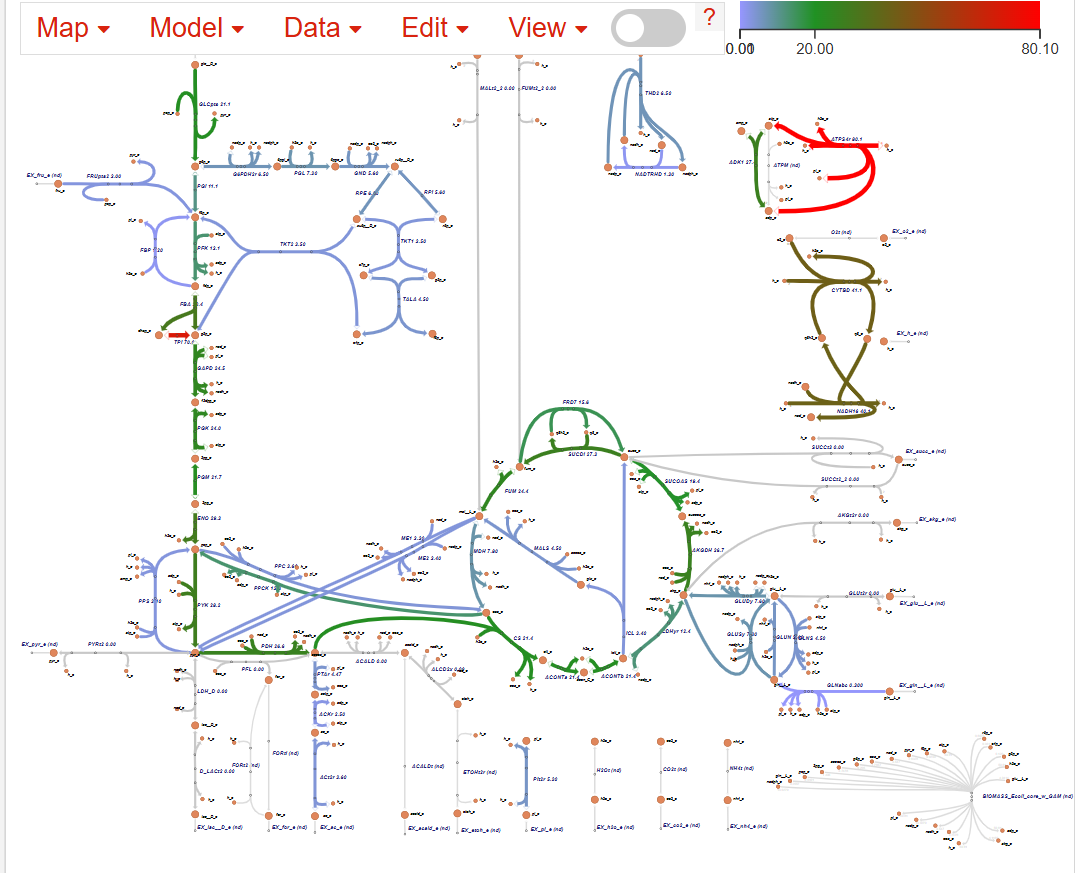
## a) Do maximal reaction activities obbey the same mass-balance pattern as steady state fluxes?
No, the maximal values describe the independently measured or estimated capacities of reaction. Mass balance constrains the ACTUAL fluxes flowing according to those capacities, not capacities themselves.
## b) Meaning of grey arrows
The grey arrows can take on 2 values: 0.00 or nd. **0.00** means that the dataset contains a maximal activity value for that particular reaction, but that maximal value is either 0.00 or is displayed as 0.00 given the displayed precision. **nd** means that the dataset does not provide the value for that particular reaction. That does not however imply anything about the maximum activity level of that reaction

In [70]:
model = cobra.io.load_json_model('e_coli_core-1.json')

In [71]:
model

Name,e_coli_core
Memory address,1cbc67fa710
Number of metabolites,72
Number of reactions,95
Number of genes,137
Number of groups,0
Objective expression,1.0*BIOMASS_Ecoli_core_w_GAM - 1.0*BIOMASS_Ecoli_core_w_GAM_reverse_712e5
Compartments,"extracellular space, cytosol"


# 2

In [72]:
activity_data=pd.read_csv("KEN3170_Assignment_2026_e_coli_core_expression.csv")
activity_data.columns=["Reaction ID", "Value"]
activity_data.head()


,Reaction ID,Value
0,PFK,13.1
1,PFL,0.0
2,PGI,11.1
3,PGK,24.0
4,PGL,7.3


In [73]:
for _, row in activity_data.iterrows(): # go through all reactions for which max activity data exists. Leave the rest intact.
    # get reaction id and max values labels for each row
    reaction_id=row["Reaction ID"]
    value= row["Value"]

    reaction=model.reactions.get_by_id(reaction_id) # extract matching data from the model

    # identify reversible reactions and desired bounds
    if reaction.lower_bound<0:
        reaction.lower_bound=-value
        reaction.upper_bound=value
    else:
        if reaction_id !="ATPM": # for reversible reactions, set requested bounds except for ATPMs lower bound
            reaction.lower_bound=0
        reaction.upper_bound=value

# separate treatment of glucose exchange
gluc_ex= model.reactions.get_by_id("EX_glc__D_e")
gluc_ex.lower_bound=-1000
gluc_ex.upper_bound=1000


In [74]:
# printing all bounds

print(f"{"Reaction":<15} {"Lower bound":>15}{"Upper bound":>15}")

for reaction in model.reactions:
    print(f"{reaction.id:<15} {reaction.lower_bound:>15.2f}{reaction.upper_bound:>15.2f}")

Reaction            Lower bound    Upper bound
PFK                        0.00          13.10
PFL                        0.00           0.00
PGI                      -11.10          11.10
PGK                      -24.00          24.00
PGL                        0.00           7.30
ACALD                     -0.00           0.00
AKGt2r                    -0.00           0.00
PGM                      -21.70          21.70
PIt2r                     -5.20           5.20
ALCD2x                    -0.00           0.00
ACALDt                 -1000.00        1000.00
ACKr                      -2.50           2.50
PPC                        0.00           3.60
ACONTa                   -21.40          21.40
ACONTb                   -21.40          21.40
ATPM                       8.39        1000.00
PPCK                       0.00          13.30
ACt2r                     -3.60           3.60
PPS                        0.00           3.10
ADK1                     -27.40          27.40
AKGDH        

# 3

In [75]:
# a)

solution1= model.optimize()
print(solution1.status)
print(solution1.objective_value)

optimal
0.8732862458582367


The objective of the model is by biomass production by default. The resulted biomas production in the presence of the implemented constraints is 0.8732862458582367.

In [76]:
# b) setting the uptake limit (lower bound in COBRApy) of glucose exchange. Upper bound stays intact.
gluc_ex.lower_bound=-5


The glucose exchange is an exchange reaction. The convention in COBRApy is to treat uptake as a lower bound. Setting it to 5 and leaving the upper bound equal to 1000 means that the whole cell can take up glucose maximally at rate of 5 mmol/gDW/h and the production(secretion) of the glucose by the cell to the environment is virtually unconstrained(1000 is a very big number). In contrast, the intra-cellular  reactions described by equations represent limits imposed by the amount/activity of available enzyme.

In [77]:
# c) Running FBA with changed gluc ex uptake constraint

solution2=model.optimize()
print(solution2.status)
print(solution2.objective_value)

optimal
0.41559777509290663


After imposing the glucose uptake limit, the biomass production decreased to 0.41559777509290663, thus by about 52.4%.  That suggests that glucose availability became a limiting factor to the growth of the biomass- the cell can no longer import enough glucose to support biomass production.

# 4

In [78]:
glc_uptake=np.arange(1,15.1,0.1) # for actual calculation
biomass_rates=[]

int_uptakes=np.arange(1,16,1) # for better visualization
int_rates=[]
# looping through uptake rates, setting gluc ex lower bounds to -uptake value, running FBA optinization and storing objective values in a biomass
# rates array
for uptake in glc_uptake:
    gluc_ex.lower_bound=-uptake
    solution=model.optimize()
    biomass_rates.append(solution.objective_value)
    if np.any(np.isclose(uptake,int_uptakes)):
        int_rates.append(solution.objective_value)

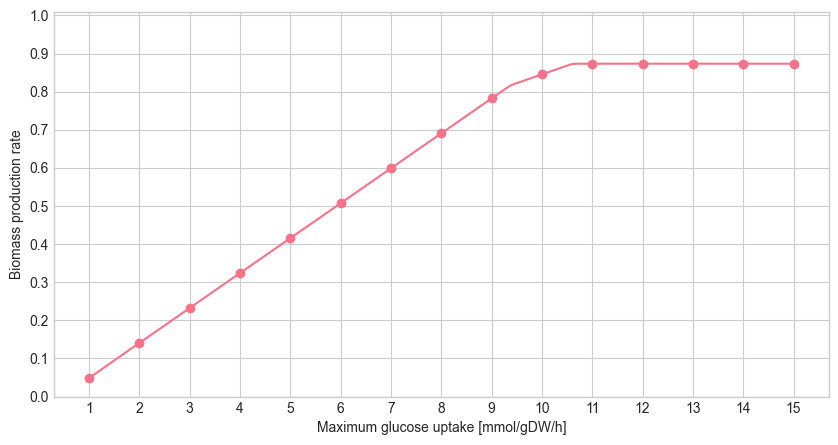

In [87]:
# plotting
plt.figure(figsize=(10,5))
plt.plot(glc_uptake, biomass_rates)
plt.grid(True)
plt.xlabel("Maximum glucose uptake [mmol/gDW/h]")
plt.xticks(np.arange(1,16,1))
plt.yticks(np.arange(0,1.1, 0.1))
plt.ylim(0,1.01)
plt.ylabel("Biomass production rate")
plt.scatter(int_uptakes, int_rates)


In [80]:
int_rates # numerical values at int uptake values for analysis (justified by the curve shape)

[0.048384972296815,
 0.14060353596759154,
 0.2322682823426966,
 0.3239330287178016,
 0.41559777509290646,
 0.5072625214680114,
 0.5989272678431168,
 0.690592014218222,
 0.7822567605933267,
 0.8452390486718341,
 0.8732862458582383,
 0.8732862458582383,
 0.8732862458582383,
 0.8732862458582383,
 0.8732862458582383]

## b)
The growth rate does not increase indefinitely with increasing glucose exchange flux bound.From the beginning to the level of ca.9.3 mmol/gDW/h the biomass production grows linearly, because glucose is limiting. After that the growth rate approaches the limit of 0.8732862458582383. For uptake levels beyond 11 mmol/gDW/h increasing glucose uptake capacity does not increase biomass production. That suggests that glusoce is no longer a limiting factor and other model constraints come into play (like imposed maximal reaction activity constraints).

## c)


In [81]:
# We will run the model once more and for each level of uptake we will observe Exchange reactionsl especially in the 2nd segment region.

exchange_reactions=[r.id for r in model.exchanges]

for uptake in glc_uptake:
    gluc_ex.lower_bound=-uptake
    solution= model.optimize()
    print(f"\nGlucose uptake bound:{uptake:.1f}")

    for reaction in exchange_reactions:
        flux=solution.fluxes[reaction]

        if abs(flux) > 0.0:
            print(reaction, flux)


Glucose uptake bound:1.0
EX_co2_e 3.9409533114228896
EX_glc__D_e -1.0
EX_h_e 0.9706025442741003
EX_h2o_e 4.293408803621791
EX_nh4_e -0.26383357694007326
EX_o2_e -3.885015444950539
EX_pi_e -0.17799379758829628

Glucose uptake bound:1.1
EX_co2_e 4.145417449182501
EX_glc__D_e -1.1
EX_h_e 1.1570519902104133
EX_h2o_e 4.565578442078248
EX_nh4_e -0.31451510928311666
EX_o2_e -4.078734108909209
EX_pi_e -0.2121858004180917

Glucose uptake bound:1.2
EX_co2_e 4.349881586942115
EX_glc__D_e -1.2000000000000002
EX_h_e 1.3435014361467095
EX_h2o_e 4.837748080534693
EX_nh4_e -0.3651966416261601
EX_o2_e -4.272452772867876
EX_pi_e -0.24637780324790334

Glucose uptake bound:1.3
EX_co2_e 4.554345724701726
EX_glc__D_e -1.3000000000000003
EX_h_e 1.5299508820830032
EX_h2o_e 5.109917718991133
EX_nh4_e -0.41587817396920373
EX_o2_e -4.466171436826542
EX_pi_e -0.28056980607770343

Glucose uptake bound:1.4
EX_co2_e 4.758809862461337
EX_glc__D_e -1.4000000000000004
EX_h_e 1.7164003280193165
EX_h2o_e 5.3820873574475

### the inspection suggests acetate secretion reaction: EX_ac_e. It becomes positive when the biomass production rate curve enters the second segment (uptake level 9.4) and and grows linearly to the uptake level 10.7, stabilizing at ca 2.5 mmol/gDW/h. Below a visualization of this phenomenon.

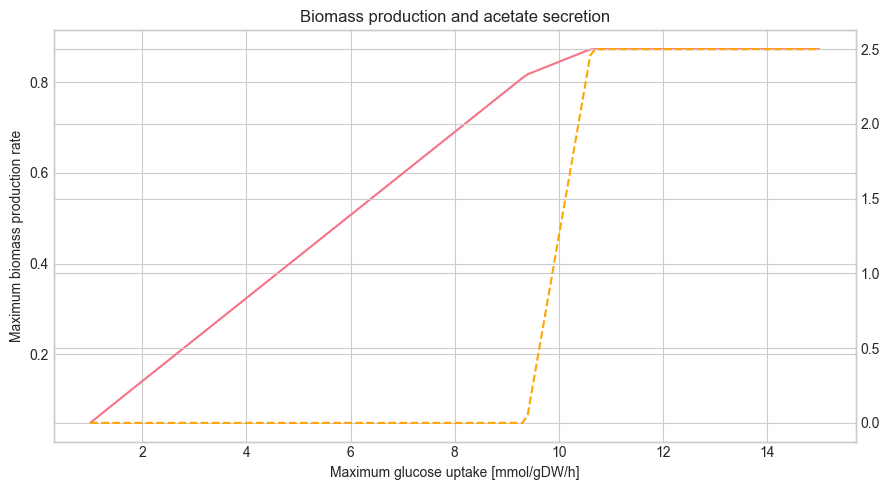

In [ ]:

# running model one more time to extract  acetate flux values
acetate_fluxes=[]
for uptake in glc_uptake:
    gluc_ex.lower_bound=-uptake
    solution=model.optimize()
    acetate_fluxes.append(solution.fluxes["EX_ac_e"])

fig, ax1= plt.subplots(figsize=(9,5))
ax1.plot(glc_uptake, biomass_rates, label="Biomass")
ax1.set_xlabel("Maximum glucose uptake [mmol/gDW/h]")
ax1.set_ylabel("Maximum biomass production rate")

ax2=ax1.twinx()
ax2.plot(glc_uptake, acetate_fluxes, linestyle="--", label="Acetate secretion", color="orange")
ax1.grid(True)
plt.title("Biomass production and acetate secretion")
plt.tight_layout()
